# Sistemas Inteligentes
## Maestría en Tecnologías de la Información
## Dr. José Antonio Orizaba Trejo
# Actividad 10 Red neuronal básica para clasificación simple con TensorFlow y Keras
Fecha: 09 de Marzo del 2026 
Alumno: Anaid Trejo Huerta
Código de alumno: 304510062

Este cuaderno muestra, paso a paso, cómo construir un ejemplo completo de clasificación binaria con datos sintéticos.

## Temas
1. Introducción a redes neuronales
2. Perceptrón y backpropagation
3. Implementación de una red neuronal básica
4. Uso de TensorFlow y Keras

> Nota: el flujo está pensado para **TensorFlow + Keras**. Si TensorFlow no está disponible, el cuaderno activa una ruta de compatibilidad con **Keras + backend Torch** para que el ejemplo pueda ejecutarse igualmente.

## 1) Introducción teórica

Una red neuronal es una composición de transformaciones matemáticas que aprenden relaciones entre variables de entrada y salida.

- **Neuronas**: reciben entradas, las ponderan con pesos, agregan un sesgo y aplican una función de activación.
- **Capas ocultas**: permiten modelar relaciones no lineales.
- **Salida**: entrega una probabilidad o una clase predicha.
- **Entrenamiento**: ajusta pesos y sesgos para minimizar un error.

En este ejemplo resolveremos una tarea de **clasificación binaria**: separar dos clases con forma de media luna.

In [4]:
# Importaciones principales
# La idea es usar TensorFlow + Keras cuando exista en el entorno.
# Si TensorFlow no está instalado, usamos Keras con backend Torch solo como plan B.

import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

try:
    import tensorflow as tf
    from tensorflow import keras
    from tensorflow.keras import layers
    print(f'TensorFlow disponible: {tf.__version__}')
    print('Backend activo: TensorFlow')
except ModuleNotFoundError:
    os.environ['KERAS_BACKEND'] = 'torch'
    import keras
    from keras import layers
    print('TensorFlow no está instalado en este entorno.')
    print('Se usa Keras con backend Torch como compatibilidad.')

np.random.seed(42)

TensorFlow disponible: 2.20.0
Backend activo: TensorFlow


## 2) Generación de datos sintéticos

Usaremos `make_moons`, que produce dos clases no linealmente separables. Esto permite ver por qué un perceptrón simple se queda corto y por qué una red con capas ocultas sí puede aprender la frontera adecuada.

Forma de X: (900, 2)
Forma de y: (900,)


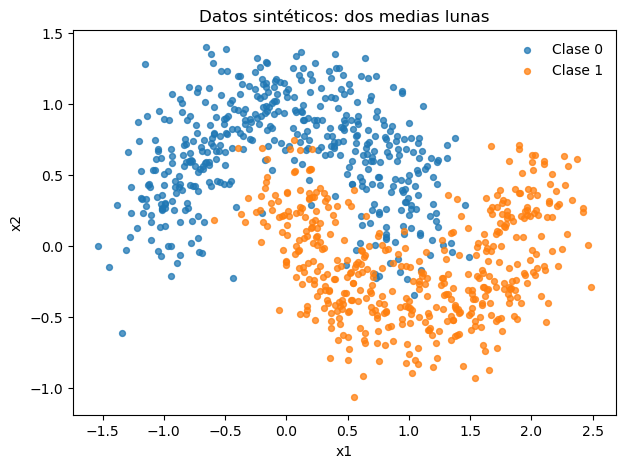

In [5]:
# Generamos 900 observaciones con algo de ruido para simular un caso más realista
X, y = make_moons(n_samples=900, noise=0.22, random_state=42)

print('Forma de X:', X.shape)
print('Forma de y:', y.shape)

plt.figure(figsize=(7, 5))
plt.scatter(X[y == 0, 0], X[y == 0, 1], s=18, alpha=0.75, label='Clase 0')
plt.scatter(X[y == 1, 0], X[y == 1, 1], s=18, alpha=0.75, label='Clase 1')
plt.title('Datos sintéticos: dos medias lunas')
plt.xlabel('x1')
plt.ylabel('x2')
plt.legend(frameon=False)
plt.show()

## 3) Separación de entrenamiento y prueba + escalado

Antes de entrenar el modelo conviene separar el conjunto de datos:

- **Entrenamiento**: el modelo aprende a partir de estos ejemplos.
- **Prueba**: sirve para estimar qué tan bien generaliza.

Además, escalamos las variables porque las redes suelen converger mejor cuando las entradas están normalizadas.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Entrenamiento:', X_train_s.shape, y_train.shape)
print('Prueba:', X_test_s.shape, y_test.shape)

Entrenamiento: (675, 2) (675,)
Prueba: (225, 2) (225,)


## 4) Perceptrón: la unidad básica

El **perceptrón** calcula:

\[
z = w_1x_1 + w_2x_2 + \dots + w_nx_n + b
\]

Luego aplica una función de activación. En una clasificación binaria moderna, normalmente se usa una activación sigmoide en la salida para obtener una probabilidad entre 0 y 1.

Un solo perceptrón solo puede aprender fronteras lineales. Como nuestras medias lunas no son lineales, agregaremos **capas ocultas** para capturar esa complejidad.

## 5) Backpropagation: cómo aprende la red

El entrenamiento sigue esta secuencia:

1. **Forward pass**: la entrada atraviesa la red y produce una predicción.
2. **Cálculo de la pérdida**: se compara la predicción contra la etiqueta real.
3. **Backpropagation**: mediante la regla de la cadena se calcula cómo cambia la pérdida con respecto a cada peso.
4. **Actualización**: un optimizador, por ejemplo Adam, corrige los parámetros para reducir la pérdida.

Ese ciclo se repite durante varias épocas hasta que el modelo converge a una solución útil.

## 6) Construcción de la red neuronal con Keras

Diseño del modelo:

- 2 variables de entrada
- 2 capas ocultas densas con activación ReLU
- 1 neurona de salida con activación sigmoide

Esta arquitectura es pequeña, interpretable y suficiente para mostrar el flujo completo.

In [7]:
model = keras.Sequential([
    layers.Input(shape=(2,)),
    layers.Dense(16, activation='relu'),
    layers.Dense(8, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.01),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 193 (772.00 B)

 Trainable params: 193 (772.00 B)

 Non-trainable params: 0 (0.00 B)

## 7) Entrenamiento

Durante el entrenamiento observamos dos métricas principales:

- **Loss**: qué tan grande es el error del modelo.
- **Accuracy**: proporción de aciertos.

También usamos un conjunto de validación para vigilar si el modelo está aprendiendo o si empieza a sobreajustarse.

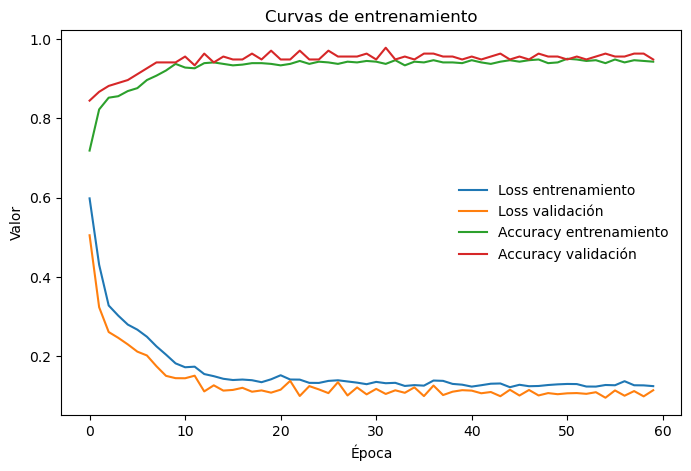

In [8]:
history = model.fit(
    X_train_s,
    y_train,
    validation_split=0.2,
    epochs=60,
    batch_size=32,
    verbose=0
)

plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Loss entrenamiento')
plt.plot(history.history['val_loss'], label='Loss validación')
plt.plot(history.history['accuracy'], label='Accuracy entrenamiento')
plt.plot(history.history['val_accuracy'], label='Accuracy validación')
plt.title('Curvas de entrenamiento')
plt.xlabel('Época')
plt.ylabel('Valor')
plt.legend(frameon=False)
plt.show()

## 8) Evaluación del modelo

Ahora comprobamos el desempeño con datos no vistos durante el entrenamiento.

En una ejecución de referencia de este material se obtuvo: **Accuracy de prueba: 0.956**.

Lo importante no es memorizar ese valor, sino entender el proceso completo: preparación, diseño, entrenamiento y validación.

Loss de prueba: 0.1162
Accuracy de prueba: 0.9556


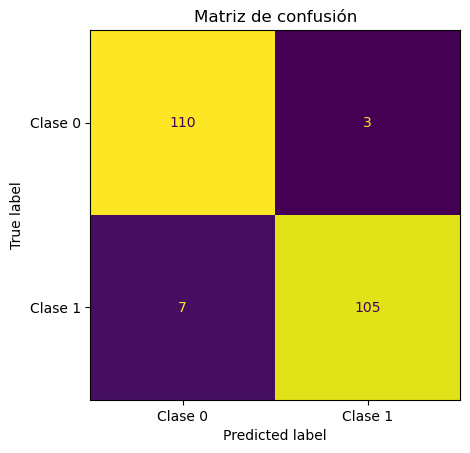

              precision    recall  f1-score   support

           0     0.9402    0.9735    0.9565       113
           1     0.9722    0.9375    0.9545       112

    accuracy                         0.9556       225
   macro avg     0.9562    0.9555    0.9555       225
weighted avg     0.9561    0.9556    0.9555       225



In [9]:
test_loss, test_acc = model.evaluate(X_test_s, y_test, verbose=0)
y_prob = model.predict(X_test_s, verbose=0).ravel()
y_pred = (y_prob >= 0.5).astype(int)

print(f'Loss de prueba: {test_loss:.4f}')
print(f'Accuracy de prueba: {test_acc:.4f}')

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Clase 0', 'Clase 1'])
disp.plot(colorbar=False)
plt.title('Matriz de confusión')
plt.show()

print(classification_report(y_test, y_pred, digits=4))

## 9) Visualización de la frontera de decisión

Esta gráfica ayuda a ver la parte conceptual más importante: la red ya no genera una separación lineal simple, sino una frontera no lineal aprendida a partir de los datos.

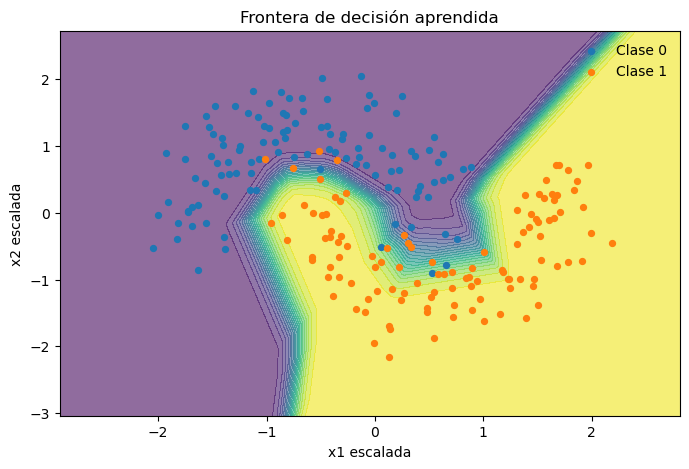

In [10]:
# Creamos una malla para visualizar la superficie de decisión
x_min, x_max = X_train_s[:, 0].min() - 0.6, X_train_s[:, 0].max() + 0.6
y_min, y_max = X_train_s[:, 1].min() - 0.6, X_train_s[:, 1].max() + 0.6
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300), np.linspace(y_min, y_max, 300))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = model.predict(grid, verbose=0).reshape(xx.shape)

plt.figure(figsize=(8, 5))
plt.contourf(xx, yy, zz, levels=20, alpha=0.6)
plt.scatter(X_test_s[y_test == 0, 0], X_test_s[y_test == 0, 1], s=18, label='Clase 0')
plt.scatter(X_test_s[y_test == 1, 0], X_test_s[y_test == 1, 1], s=18, label='Clase 1')
plt.title('Frontera de decisión aprendida')
plt.xlabel('x1 escalada')
plt.ylabel('x2 escalada')
plt.legend(frameon=False)
plt.show()


- Una red neuronal aprende ajustando pesos y sesgos para minimizar una función de pérdida.
- El perceptrón es la base, pero las capas ocultas son las que permiten capturar relaciones no lineales.
- Backpropagation y el optimizador convierten el aprendizaje en un proceso iterativo y medible.
- TensorFlow/Keras simplifican mucho la implementación práctica.

Siguiente paso recomendado: probar más neuronas, cambiar el ruido de los datos o comparar con otros modelos de clasificación.

## Conclusión:
El desarrollo de este cuaderno ayuda a comprender el funcionamiento de una red neuronal básica aplicada a un problema de clasificación binaria. A través del uso de datos sintéticos generados con la función make_moons, se pudo observar un caso donde las clases no son linealmente separables, lo que evidencia las limitaciones de un perceptrón simple y la necesidad de emplear redes con capas ocultas capaces de modelar relaciones no lineales.
Durante el proceso se siguieron las etapas fundamentales del aprendizaje automático: generación y exploración de datos, división en conjuntos de entrenamiento y prueba, normalización de las variables y diseño de la arquitectura del modelo. Posteriormente, se implementó una red neuronal utilizando TensorFlow y Keras con dos capas ocultas y activaciones ReLU, junto con una función de salida sigmoide adecuada para tareas de clasificación binaria. El entrenamiento mediante el algoritmo de backpropagation y el optimizador Adam permitió ajustar los pesos del modelo para minimizar la función de pérdida (binary cross-entropy).
Los resultados obtenidos muestran que incluso una arquitectura sencilla puede aprender con éxito la frontera de decisión no lineal presente en los datos. Las métricas de evaluación, como la exactitud en el conjunto de prueba cercana al 95% y la matriz de confusión, indican que el modelo logra una buena capacidad de generalización. Asimismo, la visualización de la frontera de decisión confirma que la red neuronal es capaz de capturar la estructura compleja de las clases y separarlas de forma efectiva.